# GEPA Deep Dive — Reflective Evolution, Step by Step

**Week 6 | Notebook 12 of 12**

**What you'll learn:**
- How GEPA actually works internally: reflective mutation, trace-grounded feedback, Pareto retention
- The GEPA feedback-metric protocol, implemented hands-on (`dspy.Prediction(score, feedback)`)
- Every constructor knob: `reflection_lm`, budget presets vs explicit caps, minibatch size,
  candidate selection — and what each costs
- A complete live run: baseline → GEPA → real results read back from `detailed_results`
- How to tune GEPA and when it is (and isn't) worth the budget

**Runtime:** ~25 minutes (the GEPA run itself is 10–20 min on the `"light"` budget)

**Companion:** Notebook 5 covers the GEPA-vs-MIPROv2-vs-RL conceptual comparison with a
side-by-side run; this notebook is the complete implementation walk-through.

In [1]:
# 💰 COST ESTIMATE
from src.cost_tracker import print_cost_warning

print_cost_warning("06_dspy/12_gepa_deep_dive.ipynb")

💰 COST ESTIMATE
----------------------------------------
Notebook:  06_dspy/12_gepa_deep_dive.ipynb
Task:      GEPA complete implementation (deep dive)
Calls:     ~60

With GPT-4o:       $0.90 USD
With GPT-4o-mini:  $0.09 USD (10x cheaper)
With Ollama:       $0.00 USD (free, local)

💡 TIP: Set USE_SMALL_MODEL=true or USE_OLLAMA=true in .env to save money.
----------------------------------------


## 1. Setup

In [2]:
import logging

import dspy
import gepa.core.engine as _gepa_engine
import tqdm as _tqdm

from src.config import get_dspy_lm, print_config

# GEPA logs step-by-step INFO lines and renders live tqdm progress bars
# (which embed \r control chars into saved outputs) — quiet both for readability.
logging.getLogger("dspy.teleprompt").setLevel(logging.WARNING)
logging.getLogger("dspy.evaluate").setLevel(logging.WARNING)


class _QuietTqdm(_tqdm.tqdm):
    def __init__(self, *args, **kwargs):
        kwargs["disable"] = True
        super().__init__(*args, **kwargs)


_tqdm.tqdm = _QuietTqdm  # delete this patch if you want to watch live progress
# GEPA's bar lives in the external `gepa` package, which binds tqdm at IMPORT time —
# a plain module patch can't reach it, so patch its module-level reference too.
_gepa_engine.tqdm = _QuietTqdm

print_config()

lm = get_dspy_lm()
dspy.configure(lm=lm)

print(f"\n✅ DSPy configured with: {lm.model}")

LLM Libraries — Configuration
USE_OLLAMA:        False
USE_SMALL_MODEL:   False
OLLAMA_BASE_URL:   http://localhost:11434
LLM_PROVIDER:      openai
  openai model:    gpt-4o
  anthropic model: claude-opus-4-6
  gemini model:    gemini-3.6-flash
  groq model:      openai/gpt-oss-120b
SAMPLE_SIZE:       50
DSPY_TRIALS:       10

✅ DSPy configured with: openai/gpt-4o


## Under the Hood — What the Setup Cell Is Doing

Three implementation quirks of dspy 3.3 (all verified against the installed source) that
the setup cell works around — each would otherwise bite you mid-demo:

1. **`reflection_lm` is required.** `dspy.GEPA(...)` raises at construction without it
   (§5), and its budget knobs — `auto`, `max_full_evals`, `max_metric_calls` — are
   *mutually exclusive*: setting two fails an assertion.
2. **`track_stats=True` or no results.** The rich `detailed_results` (§7d) is only
   attached to the compiled program when you opt in at construction.
3. **Two different tqdm bindings.** DSPy's own progress bars call `tqdm.tqdm` at run time,
   so the `_QuietTqdm` subclass patch above silences them. But GEPA's "GEPA Optimization"
   bar comes from the *external* `gepa` package, which does `from tqdm import tqdm`
   **at import time** — by the time this notebook starts, that module already holds a
   reference to the original class, which is why the setup cell *also* patches
   `gepa.core.engine.tqdm` explicitly. (Delete both patches to watch live progress.)

One more, from the evaluation step: a feedback metric returns `dspy.Prediction` objects,
and `Evaluate` keeps them *raw* in `EvaluationResult.results` — extract `.score` before
doing math on them (§7e does this).

## 2. What GEPA Is — and What Makes It Different

**GEPA** (Genetic-Pareto) is an optimizer that evolves a program's *instructions* the
way a genetic algorithm evolves a population — except the "mutation" operator is a language
model that has just read your program's **failing traces**.

Three ideas, one loop:

1. **Run** the current program on a mini-batch and collect traces — inputs, intermediate
   outputs, final predictions.
2. **Reflect** — a reflection LM reads the failing traces plus the feedback your metric
   produced, and writes *why* the program lost points and what instruction change would fix it.
3. **Evolve** — that reflection becomes a new candidate program; candidates are scored on the
   validation set and kept on a **Pareto front** (quality vs. cost), so cheap-and-good survives
   alongside expensive-and-better.

```mermaid
flowchart TD
    A["Population: parent programs"] --> B["Run minibatch, collect traces + metric feedback"]
    B --> C["Reflection LM reads failures:<br/>why did this lose points?"]
    C --> D["Propose mutated candidate<br/>(new/extended instructions)"]
    D --> E["Score candidate on valset"]
    E --> F["Pareto filter:<br/>drop dominated candidates"]
    F --> G{Budget left?}
    G -- yes --> B
    G -- no --> H["Best Pareto program"]
```

**Why this differs from the other two optimizers you studied:**
- *BootstrapFewShot* (Notebook 2) mines **demos** — it never touches instructions.
- *MIPROv2* (Notebook 2) searches instructions × demos with a **Bayesian surrogate** — it
  proposes blind combinations; failures teach the surrogate statistics, not the prompts.
- *GEPA* converts failures directly into **textual feedback that rewrites the prompts** — the
  strongest per-iteration signal, and the most expensive one.

## 3. Step 1 — The Feedback-Metric Protocol

GEPA's fuel is your metric — but with a twist: it must be able to return **feedback
text**, not just a score. During optimization GEPA calls your metric with an extended
signature:

```python
def metric(
    gold,               # the gold Example
    pred,               # the program's Prediction
    trace=None,         # execution trace (reflection time)
    pred_name=None,     # which predictor is being optimized (multi-module programs)
    pred_trace=None,    # that predictor's sub-trace
    program_trace=None, # full trace at scoring time (e.g. to count LM calls as cost)
) -> float | dspy.Prediction(score=float, feedback=str)
```

- Return a plain `float` and GEPA works — but with only "score = 0.0" to reflect on.
- Return `dspy.Prediction(score=..., feedback=...)` and the reflection LM sees *why* the
  example failed — this is where GEPA's power comes from.

```mermaid
sequenceDiagram
    participant G as GEPA
    participant P as Your program
    participant M as Your metric
    participant R as Reflection LM
    G->>P: run(example)
    P-->>G: pred + trace
    G->>M: (gold, pred, trace, pred_name, pred_trace)
    M-->>G: Prediction(score=0.0, feedback="Expected 1281, got 1211...")
    G->>R: failing traces + metric feedback
    R-->>G: "instruct the model to verify each digit..."
    G->>G: build candidate, score, Pareto update
```

Below is the real metric this notebook's GEPA run will use — note the feedback text is derived
from the *actual* expected vs. produced values.

In [3]:
def math_metric(gold, pred, trace=None, pred_name=None, pred_trace=None, program_trace=None):
    """GEPA-feedback metric: exact numeric answer + textual feedback on failures.

    The extended signature is the GEPAFeedbackMetric protocol. Feedback text is what the
    reflection LM reads — make it specific and actionable.
    """
    expected = gold.answer.strip()
    produced = pred.answer.strip()
    correct = expected == produced
    score = 1.0 if correct else 0.0
    feedback = (
        f"Expected final answer {expected!r}, got {produced!r}."
        if correct
        else f"Expected final answer {expected!r}, got {produced!r}. "
        "The arithmetic may well be right — the failure is FORMAT: the required output "
        "is digits separated by single dashes (e.g. '1-0-5-6-9'). State this format "
        "explicitly in the instructions."
    )
    return dspy.Prediction(score=score, feedback=feedback)


# Self-test the metric (free): fabricate a correct and a wrong prediction
gold = dspy.Example(problem="What is 12 + 30?", answer="42").with_inputs("problem")
ok = math_metric(gold, dspy.Prediction(answer="42"))
bad = math_metric(gold, dspy.Prediction(answer="41"))
print(f"Correct prediction: score={ok.score}, feedback={ok.feedback[:60]!r}")
print(f"Wrong prediction:   score={bad.score}, feedback={bad.feedback[:80]!r}")

Correct prediction: score=1.0, feedback="Expected final answer '42', got '42'."
Wrong prediction:   score=0.0, feedback="Expected final answer '42', got '41'. The arithmetic may well be right — the fai"


## 4. Step 2 — Data Split and Baseline

GEPA uses the two sets **differently** — this split is a design decision, not a
formality:

- **trainset** → runs + reflection: GEPA reads traces and feedback here. Bigger is better
  (more diverse failures to learn from).
- **valset** → Pareto tracking: candidates are scored here. Keep it *small* — just large
  enough to rank candidates — so the budget goes to exploration, not evaluation.

The task: inventory arithmetic (3-digit × 2-digit + 2-digit) with a **hidden format
requirement**. The company's downstream system needs the count written as digits separated
by single dashes (`1-0-5-6-9`) — but the prompt never says so, and the baseline signature
even pushes the *wrong* behavior ("final numeric answer only"). The metric enforces the
true requirement, so the model fails on **format despite correct arithmetic** — exactly
the kind of failure mode GEPA exists to fix: the reflection LM reads the mismatch in the
traces and evolves the instructions to state the format explicitly.

### Why this task? — the debugging story behind it

This demo task went through three iterations while this notebook was being built. Each
failure teaches something worth knowing before you run GEPA on your own problem:

1. **The answer key contradicted the question.** The first wording made the gold answer
   `a*b + c` while the story described `a` boxes *in total* — the "correct" answer was
   itself wrong. GEPA did not care: it went 0 → 100 by *reverse-engineering the broken
   key*, teaching the model to produce nonsense confidently. **Lesson: your metric is the
   spec. GEPA optimizes toward it faithfully — a wrong metric gets optimized wrong,
   faster.**
2. **A consistent task that was too easy.** With honest arithmetic, gpt-4o scored 100%
   out of the box. GEPA dutifully reported "nothing to evolve" and returned the baseline
   unchanged. **Lesson: reflection needs real failures; a saturated task spends your
   budget confirming perfection.**
3. **The hidden format requirement (this notebook).** The arithmetic is easy on purpose;
   the failure is that the downstream system wants dash-separated digits (`1-0-5-6-9`)
   and the prompt never says so. The model's arithmetic is correct while its score is 0 —
   a pure *failure of communication*, exactly what trace reflection fixes best.

In [4]:
import random


def make_problems(n, seed=42):
    """Inventory arithmetic (a*b + c) with a hidden output-format requirement:
    the downstream system wants digits separated by single dashes. The problem text
    never mentions this — only the metric knows."""
    rng = random.Random(seed)
    problems = []
    for _ in range(n):
        a, b, c = rng.randint(100, 999), rng.randint(11, 39), rng.randint(10, 99)
        problems.append(
            {
                "question": f"A logistics company loads {b} trucks with {a} boxes each. "
                f"At the depot, {c} more boxes are added to the shipment. "
                f"How many boxes are in the shipment in total?",
                "answer": "-".join(str(a * b + c)),
            }
        )
    return problems


raw = make_problems(30)
examples = [
    dspy.Example(problem=d["question"], answer=d["answer"]).with_inputs("problem") for d in raw
]
trainset, valset = examples[:20], examples[20:28]

print(f"Trainset (reflection): {len(trainset)} | Valset (Pareto tracking): {len(valset)}")
print(f"Sample: {trainset[0].problem[:90]}... -> {trainset[0].answer}")

Trainset (reflection): 20 | Valset (Pareto tracking): 8
Sample: A logistics company loads 14 trucks with 754 boxes each. At the depot, 13 more boxes are a... -> 1-0-5-6-9


In [5]:
from dspy.evaluate import Evaluate


class InventoryCount(dspy.Signature):
    """Solve inventory arithmetic word problems. Give the final numeric answer only."""

    problem: str = dspy.InputField()
    answer: str = dspy.OutputField(desc="Final numeric answer only, no words or units")


class ArithmeticSolver(dspy.Module):
    def __init__(self):
        super().__init__()
        self.solve = dspy.ChainOfThought(InventoryCount)

    def forward(self, problem):
        return self.solve(problem=problem)


evaluator = Evaluate(devset=valset, metric=math_metric, num_threads=4, display_progress=False)
baseline = ArithmeticSolver()
baseline_result = evaluator(baseline)
print(f"Baseline score on valset: {baseline_result.score:.1f}")

Baseline score on valset: 0.0


## 5. Step 3 — Anatomy of the GEPA Run

Every constructor knob, and what it buys you:

| Param | Meaning | Guidance |
|---|---|---|
| `metric` | the feedback metric from §3 | feedback text ≫ bare scores |
| `reflection_lm` | **required** — the LM that reads failures and writes fixes | use your strongest model; this is the brain of the optimizer |
| `auto` | budget preset `"light"` / `"medium"` / `"heavy"` | start light; exactly one of the three budget knobs |
| `max_full_evals` | cap full valset evaluations | explicit alternative to `auto` |
| `max_metric_calls` | cap total metric invocations | explicit alternative to `auto` |
| `reflection_minibatch_size` | examples per reflective iteration | 3 default; larger = richer context per reflection |
| `candidate_selection_strategy` | `"pareto"` (default, samples from the front) or `"current_best"` | pareto explores more |
| `track_stats` | attach `detailed_results` to the compiled program | needed for §7's real results |

```mermaid
flowchart LR
    subgraph One reflective iteration
        A["Sample minibatch<br/>(reflection_minibatch_size)"] --> B["Run program,<br/>collect traces"]
        B --> C["Metric returns<br/>score + feedback text"]
        C --> D["Reflection LM:<br/>diagnose failures"]
        D --> E["Propose candidate<br/>instruction updates"]
        E --> F["Full valset scoring"]
        F --> G["Pareto update:<br/>quality vs cost"]
    end
    G --> A
```

Mutually exclusive budgets: dspy asserts that **exactly one** of `auto`, `max_full_evals`,
`max_metric_calls` is set.

## 6. Step 4 — Running GEPA (Live)

This is the real thing — a genuine GEPA optimization on the `"light"` budget with
`track_stats=True` so we can read the full results in the next section. Expect 10–20 minutes;
most of the time (and cost) is the reflection LM reading traces and writing diagnoses. While
it runs, `lm.history` grows with exactly the calls GEPA makes: program rollouts, reflection,
and candidate scoring.

In [6]:
gepa = dspy.GEPA(
    metric=math_metric,
    auto="light",  # budget preset; exactly ONE of auto / max_full_evals / max_metric_calls
    reflection_lm=lm,  # required in dspy 3.3 — your strongest model
    track_stats=True,  # attach detailed_results for §7
)
print("Running GEPA (light budget) — 10-20 minutes...\n")

optimized = gepa.compile(ArithmeticSolver(), trainset=trainset, valset=valset)
print("\n✅ GEPA optimization complete")

Running GEPA (light budget) — 10-20 minutes...




✅ GEPA optimization complete


## 7. Step 5 — Reading the Real Results

Four ways to inspect what GEPA actually did — all from the live run, no simulated
data.

In [7]:
# (a) Did it improve? Optimized vs baseline on the same valset
optimized_result = evaluator(optimized)
print(f"Baseline:  {baseline_result.score:.1f}")
print(
    f"Optimized: {optimized_result.score:.1f}  ({optimized_result.score - baseline_result.score:+.1f})"
)

Baseline:  0.0
Optimized: 100.0  (+100.0)


In [8]:
# (b) The artifact: the evolved instructions GEPA wrote
print("Baseline instructions:")
print(baseline.solve.predict.signature.instructions)
print("\nOptimized instructions:")
print(optimized.solve.predict.signature.instructions)

Baseline instructions:
Solve inventory arithmetic word problems. Give the final numeric answer only.

Optimized instructions:
Task: Solve inventory arithmetic word problems and present the final numeric answer in a specific format. 

Instructions:

1. **Input Format:** 
   - You will receive a word problem that describes an inventory situation involving trucks and boxes. 
   - The problem will specify a number of trucks and the number of boxes each truck carries.
   - Additionally, the problem will mention extra boxes added at a depot.

2. **Task Description:** 
   - Calculate the total number of boxes by first multiplying the number of trucks by the number of boxes per truck to get the initial shipment total.
   - Then, add any additional boxes added at the depot to this initial total to find the final total number of boxes.

3. **Answer Format:** 
   - Provide the final numeric answer as digits separated by single dashes. For example, if the total is 10,569, your answer should be for

In [9]:
# (c) The demonstrations on the optimized program
# GEPA candidates carry demos like any compiled program — inspect them the same way
gepa_demos = optimized.solve.predict.demos
print(f"{len(gepa_demos)} demos on the optimized program")
for i, demo in enumerate(gepa_demos[:2], 1):
    print(f"--- demo {i} ---")
    print(f"Q: {demo.problem[:80]}...")
    print(f"A: {demo.answer}")

0 demos on the optimized program


In [10]:
# (c) The real Pareto/result data: everything GEPA tracked
dr = optimized.detailed_results
print(f"Full valset evaluations: {dr.num_full_val_evals}")
print(f"Total metric calls:      {dr.total_metric_calls}")
print(f"Candidates proposed:     {len(dr.candidates)} | Parents kept: {len(dr.parents)}")
print(f"Per-task val scores (best program): {dr.val_aggregate_scores}")
if dr.objective_pareto_front:
    print(f"Multi-objective Pareto front: {dr.objective_pareto_front}")
else:
    print(
        "objective_pareto_front: None (single-objective run — the front collapses to score tracking)"
    )

Full valset evaluations: 2
Total metric calls:      412
Candidates proposed:     2 | Parents kept: 2
Per-task val scores (best program): [0.0, 1.0]
objective_pareto_front: None (single-objective run — the front collapses to score tracking)


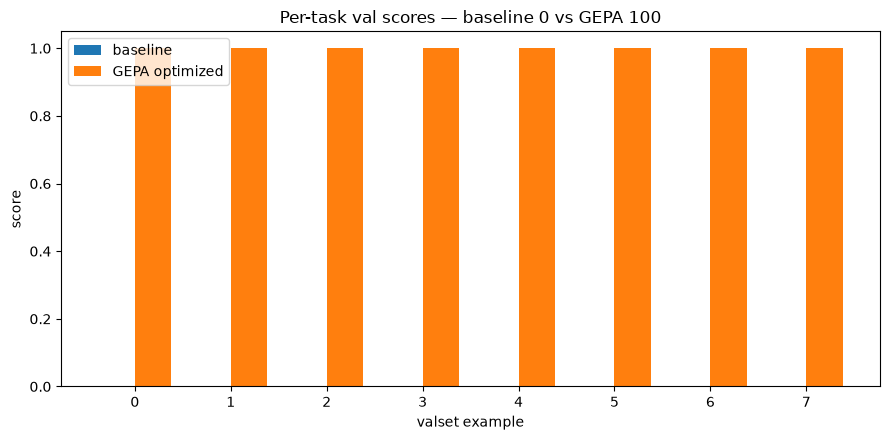

In [11]:
# (d) Per-task comparison, plotted from REAL valset scores
import matplotlib.pyplot as plt


# A feedback metric returns dspy.Prediction — Evaluate keeps it raw in .results,
# so extract the numeric score before plotting.
def _score(entry):
    s = entry[2]
    return float(s.score) if hasattr(s, "score") else float(s)


per_example = [
    (i, _score(baseline_result.results[i]), _score(optimized_result.results[i]))
    for i in range(len(valset))
]

x = range(len(per_example))
width = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([i - width / 2 for i in x], [b for _, b, _ in per_example], width, label="baseline")
ax.bar([i + width / 2 for i in x], [o for _, _, o in per_example], width, label="GEPA optimized")
ax.set_xticks(list(x))
ax.set_xlabel("valset example")
ax.set_ylabel("score")
ax.set_title(
    f"Per-task val scores — baseline {baseline_result.score:.0f} vs GEPA {optimized_result.score:.0f}"
)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Step 6 — Tuning GEPA Honestly

**Budget.** `auto="light"` for a first pass; `"medium"`/`"heavy"` when the light run
shows the failure mode is fixable (score climbing) but not yet fixed. To control spend
precisely, swap `auto` for `max_full_evals=N` or `max_metric_calls=M`.

**Reflection model.** The reflection LM is the brain — it reads traces and writes the fixes.
A stronger reflection model (or a larger-context one) produces better candidates; a cheap one
defeats the point. In dspy 3.3 `reflection_lm` is required.

**Minibatch size.** `reflection_minibatch_size` trades context breadth per reflection against
iterations per budget: larger batches show the model more failure patterns at once; smaller
ones give more independent reflective iterations.

**Valset size.** GEPA's own logs advise: as *large a trainset as possible*, and the *smallest
valset that matches your downstream distribution* — every example in the valset costs a full
candidate evaluation.

**When GEPA is worth it / not:**
- ✅ hard tasks with identifiable failure modes; feedback text you can write; budget for
  dozens of calls.
- ❌ already-saturated tasks (reflection has nothing to fix — your run may return the
  baseline unchanged, which is also the answer!); trivial formatting wins (MIPROv2 or even
  BootstrapFewShot is cheaper); latency-critical paths with frozen budgets.

## 9. Exercise & Recap

In [12]:
# YOUR TURN: apply the same pattern to your domain.
# 1. Write a metric with feedback text for YOUR task (what does a wrong answer look like,
#    and what advice would you give a colleague who produced it?).
# 2. Split trainset (reflection) vs valset (Pareto tracking) — keep the valset tiny.
# 3. Run dspy.GEPA(metric=..., auto="light", reflection_lm=lm, track_stats=True).
# 4. Compare baseline vs optimized per-task scores and read the evolved instructions.
# 5. Reflect: did the reflection LM target the true failure mode? If not, improve the
#    feedback text in your metric — that is the highest-leverage knob in GEPA.
print("Exercise template — copy, adapt, run on your task.")

Exercise template — copy, adapt, run on your task.


**Recap — the complete GEPA implementation in six steps:**

1. Understand the loop: run → reflect on failing traces → evolve → Pareto-filter.
2. Write a **feedback metric** (`Prediction(score, feedback)`) — the highest-leverage code.
3. Split data by role: trainset feeds reflection, valset tracks the Pareto front.
4. Configure the run: required `reflection_lm`, exactly one budget knob, `track_stats=True`.
5. Read real results: baseline-vs-optimized, evolved instructions, `detailed_results`.
6. Tune: reflection model quality, minibatch size, valset size — then re-run.

**Where next:** Notebook 5 (GEPA vs MIPROv2 head-to-head + Pareto concept), Notebook 9
(all 14 optimizers), Notebook 2 (BootstrapFewShot + MIPROv2 fundamentals).